# Importación de librerias

In [ ]:
!pip install "preliz==0.21.0"
!pip install "pymc==5.28.5"
!pip install "pytensor==2.38.2"
!pip install "nutpie==0.16.8"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.9 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.6 MB/s eta 0:00:00


In [ ]:
import arviz as az
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

import matplotlib.pyplot as plt

In [ ]:
import nutpie as nut
import preliz as pz

In [ ]:
print(az.__version__) # 0.22.0
print(np.__version__) # 2.0.2
print(pd.__version__) # 2.2.2
print(pm.__version__) # 5.28.5
print(nut.__version__) # 0.16.8
print(pz.__version__) # 0.21.0

# Importacion de Datos (base depurada en R)

In [ ]:
df = pd.read_csv("disparos_2023_2024_reducido.csv")
df

In [ ]:
# Acomodo algunas variables:
distancia = df["distancia_est"].to_numpy()
angulo = df["angulo_est"].to_numpy()
gol = df["gol"].to_numpy()

# Modelo 1

$$
\begin{aligned}
Y_i &\sim \text{Bernoulli}(\pi_i) \\
\pi_i &= \text{expit}(\eta_i) \\
\eta_i &= \alpha+ \beta_\text{distancia} + D_i + \beta_\text{angulo} + A_i + \beta_\text{interaccion} + A_i D_i \\
\alpha &\sim \text{Normal}(-2, 0.5) \\
\beta_\text{distancia} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{angulo} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{interaccion} &\sim \text{Normal}(0, 0.5) \\
\end{aligned}
$$

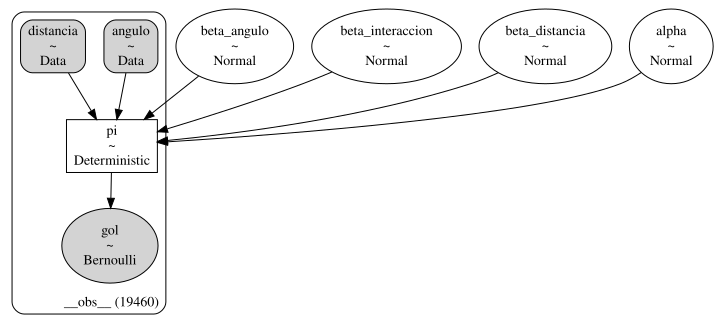

In [ ]:
coords = {
    "__obs__": np.arange(len(df))
}

# Hay que usar 'data containers' para luego simplemente reemplazar sus valores y
# correr el modelo hacia delante (i.e. obtener posteriors para "nuevas" observaciones).
with pm.Model(coords=coords) as modelo_1:
    distancia_data = pm.Data("distancia", distancia, dims="__obs__")
    angulo_data = pm.Data("angulo", angulo, dims="__obs__")

    alpha = pm.Normal("alpha", mu=-2, sigma=0.5)
    beta_distancia = pm.Normal("beta_distancia", mu=0, sigma=0.5)
    beta_angulo = pm.Normal("beta_angulo", mu=0, sigma=0.5)
    beta_interaccion = pm.Normal("beta_interaccion", mu=0, sigma=0.5)

    eta = (
        alpha
        + beta_distancia * distancia_data
        + beta_angulo * angulo_data
        + beta_interaccion * distancia_data * angulo_data
    )

    p = pm.math.invlogit(eta)

    pi = pm.Deterministic("pi", pm.math.invlogit(eta), dims="__obs__")
    pm.Bernoulli("gol", p=pi, observed=gol, dims="__obs__")

modelo_1.to_graphviz()

In [ ]:
with modelo_1:
    idata_1 = pm.sample(chains=4, draws=4000, nuts_sampler="nutpie", random_seed=1910)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,5000,0,0.37,15
,5000,0,0.38,15
,5000,0,0.42,7
,5000,0,0.39,15


In [ ]:
# Veo un resumen del modelo ajustado:
az.summary(idata_1, var_names=["alpha", "beta_angulo", "beta_distancia", "beta_interaccion"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-2.742,0.052,-2.835,-2.640,0.001,0.000,4064.0,6125.0,1.0
beta_angulo,0.641,0.122,0.415,0.873,0.002,0.001,2837.0,3985.0,1.0
beta_distancia,-0.522,0.089,-0.688,-0.354,0.002,0.001,3235.0,4883.0,1.0
beta_interaccion,0.131,0.058,0.023,0.238,0.001,0.001,2989.0,4170.0,1.0


In [ ]:
# Este modelo que acabo de ajustar sera muy pesado cuando lo descargue porque puse: pi = pm.Deterministic("pi", pm.math.invlogit(eta), dims="__obs__")
# Esa linea me esta guardando el valor de pi para cada fila de mi df. Tengo 19k de datos y 16k de muestras (aprox 300M de elementos).
# Sin embargo, no voy a sacar esa linea porque despues si que necesito algo de eso para obtener los pi en valores especificos de distancia y angulo.
# Entonces voy a sacar los pi del idata antes de descargar las muestras, pero dejandolo en esa parte del codigo.
posterior_reducido_1 = idata_1.posterior.ds.drop_vars("pi")

posterior_reducido_1.to_netcdf("muestras_modelo_1.nc")

In [ ]:
# Descargo las muestras que obtuve:
from google.colab import files
files.download("muestras_modelo_1.nc")

In [ ]:
# Ahora que ya descargue esas muestras, puedo cargar ese archivo .nc y trabajar con las muestras sin necesidad de ajustar el modelo cada vez.
from google.colab import files
files.upload()

In [ ]:
idata_1 = xr.open_dataset("muestras_modelo_1.nc")

# Modelo 2

$$
\begin{aligned}
Y_i &\sim \text{Bernoulli}(\pi_i) \\
\pi_i &= \text{expit}(\eta_i) \\
\eta_i &= \alpha_{j[i]} + \beta_\text{distancia} + D_i + \beta_\text{angulo} + A_i + \beta_\text{interaccion} + A_i D_i \\
\alpha_j &\sim \text{Normal}(-2, 0.5) \text{  para todo } j \\
\beta_\text{distancia} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{angulo} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{interaccion} &\sim \text{Normal}(0, 0.5) \\
\end{aligned}
$$

* $j$ es el índice que representa la posición, $j \in \{1, 2, 3, 4\}$.
* $j[i]$ se lee como "el valor de $j$ que le corresponde a la observación $i$-ésima".
* Luego, $\alpha_{j[i]}$ es el intercepto que le corresponde a la observacion $i$-ésima.
    * Hay tantos interceptos como posiciones.

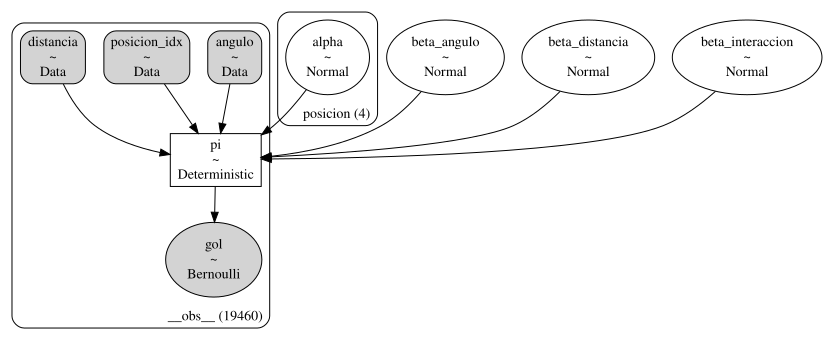

In [ ]:
# posicion_idx seria un vector con los valores de 'j'
# Que el primer valor de posicion_idx sea 1, significa que la primera observacion es de un jugador
# en la posicion `posiciones[1]`.
posiciones, posicion_idx = np.unique(df["posicion_nueva"], return_inverse=True)
coords = {
    "__obs__": np.arange(len(df)),
    "posicion": posiciones
}

with pm.Model(coords=coords) as modelo_2:
    distancia_data = pm.Data("distancia", distancia, dims="__obs__")
    angulo_data = pm.Data("angulo", angulo, dims="__obs__")
    posicion_idx_data = pm.Data("posicion_idx", posicion_idx, dims="__obs__")

    alpha = pm.Normal("alpha", mu=-2, sigma=0.5, dims="posicion") # Un intercepto para cada posicion
    beta_distancia = pm.Normal("beta_distancia", mu=0, sigma=0.5)
    beta_angulo = pm.Normal("beta_angulo", mu=0, sigma=0.5)
    beta_interaccion = pm.Normal("beta_interaccion", mu=0, sigma=0.5)

    eta = (
        alpha[posicion_idx_data] # Acá indexamos, es el alpha_j[i] de la notación
        + beta_distancia * distancia_data
        + beta_angulo * angulo_data
        + beta_interaccion * distancia_data * angulo_data
    )

    pi = pm.Deterministic("pi", pm.math.invlogit(eta), dims="__obs__")
    pm.Bernoulli("gol", p=pi, observed=gol, dims="__obs__")

modelo_2.to_graphviz()

In [ ]:
with modelo_2:
    idata_2 = pm.sample(chains=4, draws=4000, nuts_sampler="nutpie", random_seed=1910)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,5000,0,0.37,7
,5000,0,0.35,15
,5000,0,0.38,3
,5000,0,0.36,7


In [ ]:
# Veo un resumen del modelo ajustado:
az.summary(idata_2, var_names=["alpha", "beta_angulo", "beta_distancia", "beta_interaccion"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[DF],-2.933,0.102,-3.1,-2.8,7289,8138,1.00,0.0012,0.00084
alpha[FW],-2.641,0.059,-2.7,-2.5,3497,5574,1.00,0.001,0.00071
alpha[MF_no_ofen],-2.873,0.084,-3,-2.7,7451,8856,1.00,0.00097,0.00069
alpha[MF_ofen],-2.653,0.079,-2.8,-2.5,6007,8122,1.00,0.001,0.00072
beta_angulo,0.668,0.127,0.46,0.87,2038,3057,1.00,0.0028,0.002
beta_distancia,-0.467,0.092,-0.61,-0.32,2326,3678,1.00,0.0019,0.0014
beta_interaccion,0.142,0.06,0.046,0.24,2120,3261,1.00,0.0013,0.00094


In [ ]:
# Saco los pi para descargarlo:
posterior_reducido_2 = idata_2.posterior.ds.drop_vars("pi")

posterior_reducido_2.to_netcdf("muestras_modelo_2.nc")

In [ ]:
# Descargo las muestras que obtuve:
from google.colab import files
files.download("muestras_modelo_2.nc")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cargo el archivo:
from google.colab import files
files.upload()

Saving muestras_modelo_2_chequear.nc to muestras_modelo_2_chequear.nc


{'muestras_modelo_2_chequear.nc': b'\x89HDF\r\n\x1a\n\x00\x00\x00\x00\x00\x08\x08\x00\x04\x00\x10\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\n\xbd\x10\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\x00\x00\x00\x00\x00\x00\x00\x00`\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00OHDR\x02\r*\x03\x02"\x00\x00\x00\x00\x00\x03\x0c\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\n\x02\x00\x01\x00\x00\x00\x00\x15\x1c\x00\x04\x00\x00\x00\x03\n\x00\x96\x03\x00\x00\x00\x00\x00\x00(\x04\x00\x00\x00\x00\x00\x00N\x04\x00\x00\x00\x00\x00\x00\x06\x18\x00\x00\x07\x00\x01\x04\x04\x00\x00\x00\x00\x00\x00\x00\x05alpha\xac\x1e\x00\x00\x00\x00\x00\x00\x06!\x00\x00\x07\x00\x01\x04\x05\x00\x00\x00\x00\x00\x00\x00\x0ebeta_distancia\x8a\xf3\x07\x00\x00\x00\x00\x00\x06\x1e\x00\x00\x07\x00\x01\x04\x06\x00\x00\x00\x00\x

In [ ]:
idata_2 = xr.open_dataset("muestras_modelo_2.nc")

# Modelo 3

$$
\begin{aligned}
Y_i &\sim \text{Bernoulli}(\pi_i) \\
\pi_i &= \text{expit}(\eta_i) \\
\eta_i &= \alpha_{j[i]} + \gamma_{k[i]} + \beta_\text{distancia} + D_i + \beta_\text{angulo} + A_i + \beta_\text{interaccion} + A_i D_i \\
\alpha_j &\sim \text{Normal}(-2, 0.5) & \text{  para todo } j \\
\gamma_k &\sim \text{Normal}(0, \sigma^2_\gamma) & \text{  para todo } k \\
\sigma^2_\gamma &\sim \text{InvGamma}(3, 2) \\
\beta_\text{distancia} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{angulo} &\sim \text{Normal}(0, 0.5) \\
\beta_\text{interaccion} &\sim \text{Normal}(0, 0.5) \\
\end{aligned}
$$

* $k$ representa al jugador (mientras que $i$ representaba a la ocasión de gol / disparo).
* $k[i]$ es "el jugador del disparo $i$-ésimo".

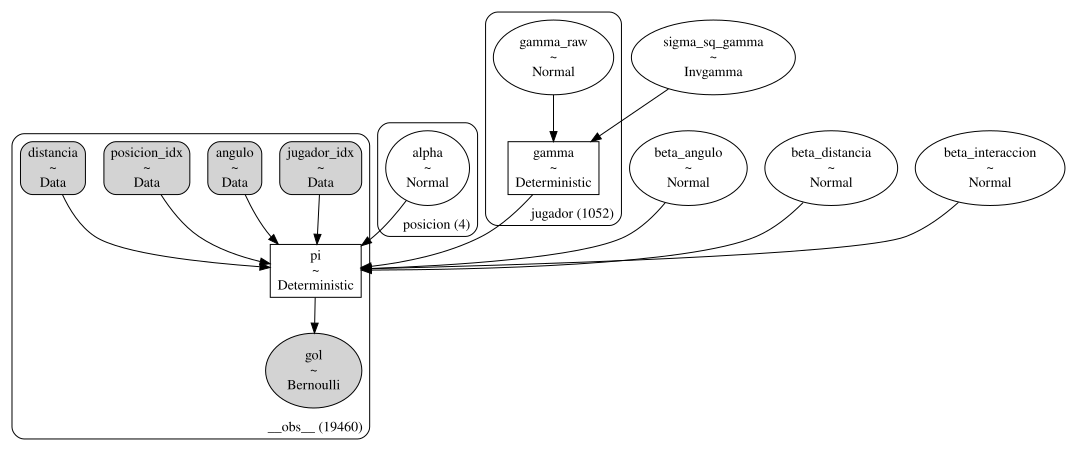

In [ ]:
posiciones, posicion_idx = np.unique(df["posicion_nueva"], return_inverse=True)
jugadores, jugador_idx = np.unique(df["id_jugador"], return_inverse=True)

coords = {
    "__obs__": np.arange(len(df)),
    "posicion": posiciones,
    "jugador": jugadores,
}

with pm.Model(coords=coords) as modelo_3:
    distancia_data = pm.Data("distancia", distancia, dims="__obs__")
    angulo_data = pm.Data("angulo", angulo, dims="__obs__")
    posicion_idx_data = pm.Data("posicion_idx", posicion_idx, dims="__obs__")
    jugador_idx_data = pm.Data("jugador_idx", jugador_idx, dims="__obs__")


    # Un intercepto para cada posicion
    alpha = pm.Normal("alpha", mu=-2, sigma=0.5, dims="posicion")

    # Una desviación del intercepto para cada jugador
    gamma_raw = pm.Normal("gamma_raw", mu=0, sigma=1, dims="jugador")
    sigma_gamma = pm.InverseGamma("sigma_sq_gamma", 5, 3) ** 0.5 # Saco raiz cuadrada, el prior es sobre la varianza
    gamma = pm.Deterministic("gamma", 0 + gamma_raw * sigma_gamma, dims="jugador")

    beta_distancia = pm.Normal("beta_distancia", mu=0, sigma=0.5)
    beta_angulo = pm.Normal("beta_angulo", mu=0, sigma=0.5)
    beta_interaccion = pm.Normal("beta_interaccion", mu=0, sigma=0.5)

    eta = (
        alpha[posicion_idx_data]
        + gamma[jugador_idx_data]
        + beta_distancia * distancia_data
        + beta_angulo * angulo_data
        + beta_interaccion * distancia_data * angulo_data
    )

    pi = pm.Deterministic("pi", pm.math.invlogit(eta), dims="__obs__")
    pm.Bernoulli("gol", p=pi, observed=gol, dims="__obs__")

modelo_3.to_graphviz()

In [ ]:
with modelo_3:
    idata_3 = pm.sample(chains=4, draws=4000, nuts_sampler="nutpie", random_seed=1910)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,5000,0,0.27,15
,5000,0,0.29,15
,5000,0,0.27,15
,5000,0,0.31,15


In [ ]:
# Veo un resumen del modelo ajustado:
az.summary(idata_3, var_names=["alpha", "sigma_sq_gamma", "beta_angulo", "beta_distancia", "beta_interaccion"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[DF],-3.006,0.11,-3.2,-2.8,5602,7319,1.00,0.0015,0.001
alpha[FW],-2.731,0.067,-2.8,-2.6,2623,5206,1.00,0.0013,0.00093
alpha[MF_no_ofen],-2.941,0.089,-3.1,-2.8,5669,8131,1.00,0.0012,0.00084
alpha[MF_ofen],-2.729,0.086,-2.9,-2.6,4410,7720,1.00,0.0013,0.00092
sigma_sq_gamma,0.1639,0.026,0.13,0.21,8275,8889,1.00,0.00029,0.00022
beta_angulo,0.695,0.126,0.49,0.9,1292,2223,1.00,0.0035,0.0025
beta_distancia,-0.467,0.092,-0.61,-0.32,1504,2658,1.00,0.0024,0.0017
beta_interaccion,0.147,0.059,0.053,0.24,1367,2358,1.00,0.0016,0.0011


In [ ]:
# Saco los pi para descargarlo:
posterior_reducido_3 = idata_3.posterior.ds.drop_vars("pi")

posterior_reducido_3.to_netcdf("muestras_modelo_3.nc")

In [ ]:
# Descargo las muestras que obtuve:
from google.colab import files
files.download("muestras_modelo_3.nc")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cargo el archivo:
from google.colab import files
files.upload()

Saving muestras_modelo_3_chequear.nc to muestras_modelo_3_chequear.nc


In [ ]:
idata_3 = xr.open_dataset("muestras_modelo_3.nc")

# xG para determinados valores de distancia y angulo

Obtenemos muestras del posterior de `pi` y de la predictiva a posteriori `gol`, luego de haber fijado valores para las covariables.

Se usa PyMC para actualizar los valores de los datos (por eso necesitamos data containers) y luego PyMC nos devuelve las muestras del posterior y de la predictiva que se necesitan.

## Modelo 1

Aca solo debo agregar la info de sobre que distancia y que angulo quiero calcular la probabilidad.

In [ ]:
with pm.model.fgraph.clone_model(modelo_1):
    pm.set_data(
        new_data={
            "distancia": [-1.109235],
            "angulo": [1.057081]
        },
        coords={"__obs__": [0]}  # solo una observación
    )

    pp = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi"],  # con esto alcanza para xG
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
# Descargo las muestras de pi para graficarlas en R:

pi_samples = pp.predictions["pi"].values.flatten()

df_pi = pd.DataFrame({"pi": pi_samples})

df_pi.to_csv("muestras_tipico_mod1.csv", index=False)

from google.colab import files
files.download("muestras_tipico_mod1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Hago todo lo mismo para otros valores de distancia y angulo:
with pm.model.fgraph.clone_model(modelo_1):
    pm.set_data(
        new_data={
            "distancia": [-1.380092],
            "angulo": [1.648544]
        },
        coords={"__obs__": [0]}  # solo una observación
    )

    pp = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi"],  # con esto alcanza para xG
        predictions=True,
        random_seed=1910,
    )

import numpy as np
import pandas as pd

pi_samples = pp.predictions["pi"].values.flatten()

df_pi = pd.DataFrame({"pi": pi_samples})

df_pi.to_csv("muestras_no_tan_tipico_mod1.csv", index=False)

from google.colab import files
files.download("muestras_no_tan_tipico_mod1.csv")

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Modelo 2

Aca hay que especificar mas variables, pero la logica es la misma. Siempre tenes como resultados muestras del posterior y de la predictiva a posteriori.

Aca predecimos para 4 disparos, todos del mismo punto, pero para diferentes posiciones.

In [ ]:
with pm.model.fgraph.clone_model(modelo_2):
    pm.set_data(
        new_data={
            "distancia": [-1.109235, -1.109235, -1.109235, -1.109235],
            "angulo": [1.057081, 1.057081, 1.057081, 1.057081],
            "posicion_idx": [0, 1, 2, 3]
        },
        coords={"__obs__": [0, 1, 2, 3]}
    )
    pp2 = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
# Y hago todo esto para descargarlo de una forma que pueda manejarlo comodo en R:

# Extraer dimensiones
pi_array = pp2.predictions["pi"].values  # (chain, draw, __obs__)

n_chain, n_draw, n_obs = pi_array.shape

# Aplanar
pi_flat = pi_array.reshape(-1)

# Crear vector de posiciones (repitiendo cada índice correctamente)
posiciones = np.tile(np.arange(n_obs), n_chain * n_draw)

# Armar dataframe
df_pi = pd.DataFrame({
    "pi": pi_flat,
    "posicion": posiciones
})

# Guardar
df_pi.to_csv("muestras_tipico_mod2.csv", index=False)

from google.colab import files
files.download("muestras_tipico_mod2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Hago lo mismo para otros valores de distancia y angulo:
with pm.model.fgraph.clone_model(modelo_2):
    pm.set_data(
        new_data={
            "distancia": [-1.380092, -1.380092, -1.380092, -1.380092],
            "angulo": [1.648544, 1.648544, 1.648544, 1.648544],
            "posicion_idx": [0, 1, 2, 3]
        },
        coords={"__obs__": [0, 1, 2, 3]}
    )
    pp2 = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

import numpy as np
import pandas as pd

# Extraer dimensiones
pi_array = pp2.predictions["pi"].values  # (chain, draw, __obs__)

n_chain, n_draw, n_obs = pi_array.shape

# Aplanar
pi_flat = pi_array.reshape(-1)

# Crear vector de posiciones (repitiendo cada índice correctamente)
posiciones = np.tile(np.arange(n_obs), n_chain * n_draw)

# Armar dataframe
df_pi = pd.DataFrame({
    "pi": pi_flat,
    "posicion": posiciones
})

# Guardar
df_pi.to_csv("muestras_no_tan_tipico_mod2.csv", index=False)

from google.colab import files
files.download("muestras_no_tan_tipico_mod2.csv")

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Modelo 3 (con un loop)

Aca hay que especificar las mismas variables que antes, incluido el jugador.

En este caso podemos tambien poner todos los disparos de un mismo jugador, y luego obtener la predictiva a posteriori de la cantidad de goles que se espera que haga ese jugador.


In [ ]:
# Voy a hacer algo similar a lo de los modelos anteriores, pero iterando para que pueda hacerlo con varios jugadores.
# Quiero ver como cambia la probabilidad de gol para una misma distancia y angulo, pero para distintos jugadores.
# Debo aclarar en que posicion juega cada uno de ellos.

dist_fija = -1.109235
angulo_fijo = 1.057081

posiciones_ids = {
    109298: "DF", 174813: "DF", 523418: "DF", 724317: "DF", 725483: "DF",
    907723: "DF", 939965: "DF", 1029392: "DF", 1242173: "DF", 1606009: "DF",

    211821: "FW", 318530: "FW", 323385: "FW", 576037: "FW", 785840: "FW",
    918846: "FW", 1117950: "FW", 1130230: "FW", 1132960: "FW", 1216074: "FW",

    130118: "MF_no_ofen", 161344: "MF_no_ofen", 164035: "MF_no_ofen", 845709: "MF_no_ofen", 857214: "MF_no_ofen",
    902983: "MF_no_ofen", 1075450: "MF_no_ofen", 1128929: "MF_no_ofen", 1485760: "MF_no_ofen", 1681682: "MF_no_ofen",

    207617: "MF_ofen", 346379: "MF_ofen", 362229: "MF_ofen", 469616: "MF_ofen", 636958: "MF_ofen",
    838234: "MF_ofen", 845944: "MF_ofen", 949735: "MF_ofen", 1094295: "MF_ofen", 1607566: "MF_ofen"
}

resultados_pi = []

for jugador_id, posicion_jugador in posiciones_ids.items():

    # Chequeo
    idx_jugador_arr = np.argwhere(jugadores == jugador_id)
    if len(idx_jugador_arr) == 0:
        continue
    idx_jugador = idx_jugador_arr.item()

    idx_posicion_arr = np.argwhere(posiciones == posicion_jugador)
    if len(idx_posicion_arr) == 0:
        continue
    idx_posicion = idx_posicion_arr.item()

    with pm.model.fgraph.clone_model(modelo_3):
        pm.set_data(
            new_data={
                "distancia": np.array([dist_fija]),
                "angulo": np.array([angulo_fijo]),
                "posicion_idx": [idx_posicion],
                "jugador_idx": [idx_jugador],
            },
            coords={"__obs__": np.arange(1)}
        )

        pp = pm.sample_posterior_predictive(
            idata_3,
            var_names=["pi"],
            predictions=True,
            random_seed=1910,
        )

    pi_vals = pp.predictions["pi"].values.flatten()

    for i, pi in enumerate(pi_vals):
        resultados_pi.append({
            "id_jugador": jugador_id,
            "posicion": posicion_jugador,
            "draw": i,
            "pi": pi
        })

# DataFrame final:
df_pi = pd.DataFrame(resultados_pi)

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━  88% 0:00:01 / 0:00:00

In [ ]:
# Guardo pero en un formato comprimido:
df_pi.to_csv("muestras_tipico_mod3.gz", index=False, compression="gzip")

from google.colab import files
files.download("muestras_tipico_mod3.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Hago lo mismo pero para otros valores de distancia y angulo:

dist_fija = -1.380092
angulo_fijo = 1.648544

posiciones_ids = {
    109298: "DF", 174813: "DF", 523418: "DF", 724317: "DF", 725483: "DF",
    907723: "DF", 939965: "DF", 1029392: "DF", 1242173: "DF", 1606009: "DF",

    211821: "FW", 318530: "FW", 323385: "FW", 576037: "FW", 785840: "FW",
    918846: "FW", 1117950: "FW", 1130230: "FW", 1132960: "FW", 1216074: "FW",

    130118: "MF_no_ofen", 161344: "MF_no_ofen", 164035: "MF_no_ofen", 845709: "MF_no_ofen", 857214: "MF_no_ofen",
    902983: "MF_no_ofen", 1075450: "MF_no_ofen", 1128929: "MF_no_ofen", 1485760: "MF_no_ofen", 1681682: "MF_no_ofen",

    207617: "MF_ofen", 346379: "MF_ofen", 362229: "MF_ofen", 469616: "MF_ofen", 636958: "MF_ofen",
    838234: "MF_ofen", 845944: "MF_ofen", 949735: "MF_ofen", 1094295: "MF_ofen", 1607566: "MF_ofen"
}

resultados_pi = []

for jugador_id, posicion_jugador in posiciones_ids.items():

    idx_jugador_arr = np.argwhere(jugadores == jugador_id)
    if len(idx_jugador_arr) == 0:
        continue
    idx_jugador = idx_jugador_arr.item()

    idx_posicion_arr = np.argwhere(posiciones == posicion_jugador)
    if len(idx_posicion_arr) == 0:
        continue
    idx_posicion = idx_posicion_arr.item()

    with pm.model.fgraph.clone_model(modelo_3):
        pm.set_data(
            new_data={
                "distancia": np.array([dist_fija]),
                "angulo": np.array([angulo_fijo]),
                "posicion_idx": [idx_posicion],
                "jugador_idx": [idx_jugador],
            },
            coords={"__obs__": np.arange(1)}
        )

        pp = pm.sample_posterior_predictive(
            idata_3,
            var_names=["pi"],
            predictions=True,
            random_seed=1910,
        )

    pi_vals = pp.predictions["pi"].values.flatten()

    for i, pi in enumerate(pi_vals):
        resultados_pi.append({
            "id_jugador": jugador_id,
            "posicion": posicion_jugador,
            "draw": i,
            "pi": pi
        })

# DataFrame final:
df_pi = pd.DataFrame(resultados_pi)

In [ ]:
# Guardo pero en un formato comprimido:
df_pi.to_csv("muestras_no_tan_tipico_mod3.gz", index=False, compression="gzip")

from google.colab import files
files.download("muestras_no_tan_tipico_mod3.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Distribuciones Predictivas a Posteriori por jugador

In [ ]:
posiciones, posicion_idx = np.unique(df["posicion_nueva"], return_inverse=True)
jugadores, jugador_idx = np.unique(df["id_jugador"], return_inverse=True)

In [ ]:
# Construyo un df con los disparos de cada jugador:
df_maravilla = df[df["id_jugador"] == 882933]  # 122 filas
df_merentiel = df[df["id_jugador"] == 826418]  # 104 filas
df_dominguez = df[df["id_jugador"] == 1316088] # 95 filas

In [ ]:
# Extraigo los ID de estos jugadores segun el modelo
id_maravilla = np.argwhere(jugadores == 882933).item()
id_merentiel = np.argwhere(jugadores == 826418).item()
id_dominguez = np.argwhere(jugadores == 1316088).item()

In [ ]:
# Les pongo sus respectivas posiciones:
posicion_maravilla = np.argwhere(posiciones == "FW").item()
posicion_merentiel = np.argwhere(posiciones == "FW").item()
posicion_dominguez = np.argwhere(posiciones == "FW").item()

In [ ]:
# Chequeo que verdaramente sean los indices de estos jugadores.
(jugador_idx == id_maravilla).sum() # 122
(jugador_idx == id_merentiel).sum() # 104
(jugador_idx == id_dominguez).sum() # 95

np.int64(95)

Modelo 1:

In [ ]:
with pm.model.fgraph.clone_model(modelo_1):
    pm.set_data(
        new_data={
            "distancia": df_maravilla["distancia_est"].to_numpy(),
            "angulo": df_maravilla["angulo_est"].to_numpy(),
        },
        coords={"__obs__": np.arange(len(df_maravilla))}
    )

    pp1_maravilla = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_1):
    pm.set_data(
        new_data={
            "distancia": df_merentiel["distancia_est"].to_numpy(),
            "angulo": df_merentiel["angulo_est"].to_numpy(),
        },
        coords={"__obs__": np.arange(len(df_merentiel))}
    )

    pp1_merentiel = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_1):
    pm.set_data(
        new_data={
            "distancia": df_dominguez["distancia_est"].to_numpy(),
            "angulo": df_dominguez["angulo_est"].to_numpy(),
        },
        coords={"__obs__": np.arange(len(df_dominguez))}
    )

    pp1_dominguez = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
pp1_goles_maravilla = pp1_maravilla.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp1_goles_merentiel = pp1_merentiel.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp1_goles_dominguez = pp1_dominguez.predictions["gol"].sum("__obs__").to_numpy().flatten()

goles_maravilla, conteo_maravilla = np.unique(pp1_goles_maravilla, return_counts=True)
goles_merentiel, conteo_merentiel = np.unique(pp1_goles_merentiel, return_counts=True)
goles_dominguez, conteo_dominguez = np.unique(pp1_goles_dominguez, return_counts=True)

# Normalizamos para obtener probabilidades
probabilidad_maravilla = conteo_maravilla / conteo_maravilla.sum()
probabilidad_merentiel = conteo_merentiel / conteo_merentiel.sum()
probabilidad_dominguez = conteo_dominguez / conteo_dominguez.sum()

In [ ]:
# Descargo los resultados:
pd.DataFrame({"pp1_goles_maravilla": pp1_goles_maravilla}).to_csv("pp1_goles_maravilla.csv", index=False)
pd.DataFrame({"pp1_goles_merentiel": pp1_goles_merentiel}).to_csv("pp1_goles_merentiel.csv", index=False)
pd.DataFrame({"pp1_goles_dominguez": pp1_goles_dominguez}).to_csv("pp1_goles_dominguez.csv", index=False)

from google.colab import files
files.download("pp1_goles_maravilla.csv")
files.download("pp1_goles_merentiel.csv")
files.download("pp1_goles_dominguez.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo 2:

In [ ]:
with pm.model.fgraph.clone_model(modelo_2):
    pm.set_data(
        new_data={
            "distancia": df_maravilla["distancia_est"].to_numpy(),
            "angulo": df_maravilla["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_maravilla] * len(df_maravilla),
        },
        coords={"__obs__": np.arange(len(df_maravilla))}
    )
    pp2_maravilla = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_2):
    pm.set_data(
        new_data={
            "distancia": df_merentiel["distancia_est"].to_numpy(),
            "angulo": df_merentiel["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_merentiel] * len(df_merentiel),
        },
        coords={"__obs__": np.arange(len(df_merentiel))}
    )
    pp2_merentiel = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_2):
    pm.set_data(
        new_data={
            "distancia": df_dominguez["distancia_est"].to_numpy(),
            "angulo": df_dominguez["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_dominguez] * len(df_dominguez),
        },
        coords={"__obs__": np.arange(len(df_dominguez))}
    )
    pp2_dominguez = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
pp2_goles_maravilla = pp2_maravilla.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp2_goles_merentiel = pp2_merentiel.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp2_goles_dominguez = pp2_dominguez.predictions["gol"].sum("__obs__").to_numpy().flatten()

goles_maravilla, conteo_maravilla = np.unique(pp2_goles_maravilla, return_counts=True)
goles_merentiel, conteo_merentiel = np.unique(pp2_goles_merentiel, return_counts=True)
goles_dominguez, conteo_dominguez = np.unique(pp2_goles_dominguez, return_counts=True)

# Normalizamos para obtener probabilidades
probabilidad_maravilla = conteo_maravilla / conteo_maravilla.sum()
probabilidad_merentiel = conteo_merentiel / conteo_merentiel.sum()
probabilidad_dominguez = conteo_dominguez / conteo_dominguez.sum()

In [ ]:
# Descargo los resultados:
pd.DataFrame({"pp2_goles_maravilla": pp2_goles_maravilla}).to_csv("pp2_goles_maravilla.csv", index=False)
pd.DataFrame({"pp2_goles_merentiel": pp2_goles_merentiel}).to_csv("pp2_goles_merentiel.csv", index=False)
pd.DataFrame({"pp2_goles_dominguez": pp2_goles_dominguez}).to_csv("pp2_goles_dominguez.csv", index=False)

from google.colab import files
files.download("pp2_goles_maravilla.csv")
files.download("pp2_goles_merentiel.csv")
files.download("pp2_goles_dominguez.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo 3:

In [ ]:
with pm.model.fgraph.clone_model(modelo_3):
    pm.set_data(
        new_data={
            "distancia": df_maravilla["distancia_est"].to_numpy(),
            "angulo": df_maravilla["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_maravilla] * len(df_maravilla), # 122 veces el 1
            "jugador_idx": [id_maravilla] * len(df_maravilla) , # 122 veces el 420
        },
        coords={"__obs__": np.arange(len(df_maravilla))}
    )
    pp3_maravilla = pm.sample_posterior_predictive(
        idata_3,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_3):
    pm.set_data(
        new_data={
            "distancia": df_merentiel["distancia_est"].to_numpy(),
            "angulo": df_merentiel["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_merentiel] * len(df_merentiel),
            "jugador_idx": [id_merentiel] * len(df_merentiel) ,
        },
        coords={"__obs__": np.arange(len(df_merentiel))}
    )
    pp3_merentiel = pm.sample_posterior_predictive(
        idata_3,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
with pm.model.fgraph.clone_model(modelo_3):
    pm.set_data(
        new_data={
            "distancia": df_dominguez["distancia_est"].to_numpy(),
            "angulo": df_dominguez["angulo_est"].to_numpy(),
            "posicion_idx": [posicion_dominguez] * len(df_dominguez),
            "jugador_idx": [id_dominguez] * len(df_dominguez) ,
        },
        coords={"__obs__": np.arange(len(df_dominguez))}
    )
    pp3_dominguez = pm.sample_posterior_predictive(
        idata_3,
        var_names=["pi", "gol"],
        predictions=True,
        random_seed=1910,
    )

Output()

In [ ]:
pp3_goles_maravilla = pp3_maravilla.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp3_goles_merentiel = pp3_merentiel.predictions["gol"].sum("__obs__").to_numpy().flatten()
pp3_goles_dominguez = pp3_dominguez.predictions["gol"].sum("__obs__").to_numpy().flatten()

goles_maravilla, conteo_maravilla = np.unique(pp3_goles_maravilla, return_counts=True)
goles_merentiel, conteo_merentiel = np.unique(pp3_goles_merentiel, return_counts=True)
goles_dominguez, conteo_dominguez = np.unique(pp3_goles_dominguez, return_counts=True)

# Normalizamos para obtener probabilidades
probabilidad_maravilla = conteo_maravilla / conteo_maravilla.sum()
probabilidad_merentiel = conteo_merentiel / conteo_merentiel.sum()
probabilidad_dominguez = conteo_dominguez / conteo_dominguez.sum()

In [ ]:
# Descargo los resultados:
pd.DataFrame({"pp3_goles_maravilla": pp3_goles_maravilla}).to_csv("pp3_goles_maravilla.csv", index=False)
pd.DataFrame({"pp3_goles_merentiel": pp3_goles_merentiel}).to_csv("pp3_goles_merentiel.csv", index=False)
pd.DataFrame({"pp3_goles_dominguez": pp3_goles_dominguez}).to_csv("pp3_goles_dominguez.csv", index=False)

from google.colab import files
files.download("pp3_goles_maravilla.csv")
files.download("pp3_goles_merentiel.csv")
files.download("pp3_goles_dominguez.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Distribucion Predictiva a Posteriori del total de goles.

In [ ]:
with modelo_1:
    ppc_1 = pm.sample_posterior_predictive(
        idata_1,
        var_names=["gol"],
        random_seed=1910
    )

with modelo_2:
    ppc_2 = pm.sample_posterior_predictive(
        idata_2,
        var_names=["gol"],
        random_seed=1910
    )

with modelo_3:
    ppc_3 = pm.sample_posterior_predictive(
        idata_3,
        var_names=["gol"],
        random_seed=1910
    )

Output()

Output()

Output()

In [ ]:
goles_totales_1 = (
    ppc_1.posterior_predictive["gol"]
    .sum(dim="__obs__")
    .values
    .flatten()
)

goles_totales_2 = (
    ppc_2.posterior_predictive["gol"]
    .sum(dim="__obs__")
    .values
    .flatten()
)

goles_totales_3 = (
    ppc_3.posterior_predictive["gol"]
    .sum(dim="__obs__")
    .values
    .flatten()
)

In [ ]:
df_goles1 = pd.DataFrame({
    "pp_goles": goles_totales_1
})

df_goles2 = pd.DataFrame({
    "pp_goles": goles_totales_2
})

df_goles3 = pd.DataFrame({
    "pp_goles": goles_totales_3
})


df_goles1.to_csv("pp1_goles_totales.csv", index=False)
df_goles2.to_csv("pp2_goles_totales.csv", index=False)
df_goles3.to_csv("pp3_goles_totales.csv", index=False)

In [ ]:
from google.colab import files
files.download("pp1_goles_totales.csv")
files.download("pp2_goles_totales.csv")
files.download("pp3_goles_totales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Descargo las muestras de 40 jugadores

Descargo las muestras de 40 jugadores representativos sin diferenciar por posición.

Primero los de menor y mayor media, junto con 38 jugadores equiespaciados en sus valores medios.

In [ ]:
df_gamma = az.extract(idata_3, var_names=["gamma"], combined=True).to_dataframe()

In [ ]:
coords = {"jugador": jugadores}

In [ ]:
df_gamma = df_gamma.reset_index()

In [ ]:
media_gamma = (
    df_gamma
    .groupby("jugador")["gamma"]
    .mean()
    .reset_index(name="media_gamma")
)

In [ ]:
# Ordenar por la media:
media_gamma_ordenado = media_gamma.sort_values("media_gamma").reset_index(drop=True)
n = len(media_gamma_ordenado)

# 40 puntos equiespaciados en toda la distribución:
idx = np.linspace(0, n-1, 40).round().astype(int)
jugadores_seleccionados = media_gamma_ordenado.iloc[idx]

In [ ]:
ids_seleccionados = jugadores_seleccionados["jugador"].tolist()

df_gamma_final = df_gamma[df_gamma["jugador"].isin(ids_seleccionados)]

In [ ]:
df_gamma_final.to_csv("muestras_40_jugadores_equiespaciados.csv", index=False)

from google.colab import files
files.download("muestras_40_jugadores_equiespaciados.csv")

Después 40 jugadores considerando: 5 con menor media, 5 con mayor media y 30 del medio con valores medios equiespaciados

In [ ]:
# Ordenar:
media_gamma_ordenado = media_gamma.sort_values("media_gamma").reset_index(drop=True)
n = len(media_gamma_ordenado)

# Extremos:
extremos_bajos = media_gamma_ordenado.iloc[:5]
extremos_altos = media_gamma_ordenado.iloc[-5:]

# Parte del medio (excluyendo extremos):
medio = media_gamma_ordenado.iloc[5:-5].reset_index(drop=True)
n_medio = len(medio)

# 30 equiespaciados en el medio:
idx_medio = np.linspace(0, n_medio - 1, 30).round().astype(int)
muestra_medio = medio.iloc[idx_medio]

# Combinar todo:
jugadores_seleccionados = (
    pd.concat([extremos_bajos, muestra_medio, extremos_altos])
    .drop_duplicates()
    .reset_index(drop=True)
)

In [ ]:
ids_seleccionados = jugadores_seleccionados["jugador"].tolist()

df_gamma_final = df_gamma[df_gamma["jugador"].isin(ids_seleccionados)]

In [ ]:
from google.colab import files
df_gamma_final.to_csv("muestras_40_jugadores_5_y_5.csv", index=False)
files.download("muestras_40_jugadores_5_y_5.csv")

# Descargo las muestras de 6 jugadores específicos.

Acá voy a intentar descargar las muestras para algunos jugadores (3 buenos y 3 malos).

In [ ]:
df_gamma = az.extract(idata_3, var_names=["gamma"], combined=True).to_dataframe()

In [ ]:
coords = {"jugador": jugadores}

In [ ]:
df_gamma = df_gamma.reset_index()

In [ ]:
ids = [882933, 267894, 826418, 245345, 1200746, 1316088]

df_gamma_filtrado = df_gamma[df_gamma["jugador"].isin(ids)]

In [ ]:
df_gamma_filtrado.to_csv("muestras_6_jugadores_especificos.csv", index=False)

In [ ]:
from google.colab import files
files.download("muestras_6_jugadores_especificos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Descargo una muestra de 10 jugadores por posición.

In [ ]:
df_gamma = az.extract(idata_3, var_names=["gamma"], combined=True).to_dataframe()

In [ ]:
coords = {"jugador": jugadores}

In [ ]:
df_gamma = df_gamma.reset_index()

In [ ]:
media_gamma = (
    df_gamma
    .groupby("jugador")["gamma"]
    .mean()
    .reset_index(name="media_gamma")
)

In [ ]:
jugador_pos = (
    df[["id_jugador", "posicion_nueva"]]
    .drop_duplicates()
    .rename(columns={"id_jugador": "jugador"})
)

media_gamma = media_gamma.merge(jugador_pos, on="jugador")

In [ ]:
import numpy as np

def seleccionar_jugadores(df_pos):

    df_pos = df_pos.sort_values("media_gamma").reset_index(drop=True)
    n = len(df_pos)

    # posiciones representativas
    idx = np.linspace(0, n-1, 10).round().astype(int)

    return df_pos.iloc[idx]

In [ ]:
jugadores_seleccionados = (
    media_gamma
    .groupby("posicion_nueva", group_keys=False)
    .apply(seleccionar_jugadores)
)

/tmp/ipykernel_21566/1853038064.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(seleccionar_jugadores)


In [ ]:
jugadores_seleccionados.groupby("posicion_nueva").size()

,0
posicion_nueva,
DF,10
FW,10
MF_no_ofen,10
MF_ofen,10


In [ ]:
ids_seleccionados = jugadores_seleccionados["jugador"].tolist()

df_gamma_final = df_gamma[df_gamma["jugador"].isin(ids_seleccionados)]

In [ ]:
df_gamma_final.to_csv("muestras_10_jugadores_por_posicion.csv", index=False)

from google.colab import files
files.download("muestras_10_jugadores_por_posicion.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
tabla_posiciones = jugadores_seleccionados[["jugador", "posicion_nueva"]].sort_values(["posicion_nueva", "jugador"])


In [ ]:
tabla_posiciones.to_csv("posiciones_de_los_10_por_posicion.csv", index=False)

from google.colab import files
files.download("posiciones_de_los_10_por_posicion.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Base para la construccion de metricas

In [ ]:
# Obtener muestras posteriores de pi (xG estimado por el modelo)
with modelo_1:
    posterior_pred = pm.sample_posterior_predictive(
        idata_1,
        var_names=["pi"],
        predictions=True,
        random_seed=1910
    )

# Extraer muestras
# dimensiones: (chain, draw, observacion)
pi_samples = posterior_pred.predictions["pi"].values

# Media posterior del xG para cada disparo
media_xG = pi_samples.mean(axis=(0, 1))

# Intervalo de credibilidad al 90%
lower = np.quantile(pi_samples, 0.05, axis=(0, 1))
upper = np.quantile(pi_samples, 0.95, axis=(0, 1))

# Crear dataframe reducido
df_salida = pd.DataFrame({
    "Unnamed: 0": df["Unnamed: 0"],
    "xG_media_posterior": media_xG,
    "xG_cubierto": (
        (df["xG"] >= lower) &
        (df["xG"] <= upper)
    ).astype(int)
})

# Guardar y descargar
df_salida.to_csv("df_con_cobertura_xG_mod1.csv", index=False)

from google.colab import files
files.download("df_con_cobertura_xG_mod1.csv")

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Obtener muestras posteriores de pi (xG estimado por el modelo)
with modelo_2:
    posterior_pred = pm.sample_posterior_predictive(
        idata_2,
        var_names=["pi"],
        predictions=True,
        random_seed=1910
    )

# Extraer muestras
# dimensiones: (chain, draw, observacion)
pi_samples = posterior_pred.predictions["pi"].values

# Media posterior del xG para cada disparo
media_xG = pi_samples.mean(axis=(0, 1))

# Intervalo de credibilidad al 90%
lower = np.quantile(pi_samples, 0.05, axis=(0, 1))
upper = np.quantile(pi_samples, 0.95, axis=(0, 1))

# Crear dataframe reducido
df_salida = pd.DataFrame({
    "Unnamed: 0": df["Unnamed: 0"],
    "xG_media_posterior": media_xG,
    "xG_cubierto": (
        (df["xG"] >= lower) &
        (df["xG"] <= upper)
    ).astype(int)
})

# Guardar y descargar
df_salida.to_csv("df_con_cobertura_xG_mod2.csv", index=False)

from google.colab import files
files.download("df_con_cobertura_xG_mod2.csv")

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Obtener muestras posteriores de pi (xG estimado por el modelo)
with modelo_3:
    posterior_pred = pm.sample_posterior_predictive(
        idata_3,
        var_names=["pi"],
        predictions=True,
        random_seed=1910
    )

# Extraer muestras
# dimensiones: (chain, draw, observacion)
pi_samples = posterior_pred.predictions["pi"].values

# Media posterior del xG para cada disparo
media_xG = pi_samples.mean(axis=(0, 1))

# Intervalo de credibilidad al 90%
lower = np.quantile(pi_samples, 0.05, axis=(0, 1))
upper = np.quantile(pi_samples, 0.95, axis=(0, 1))

# Crear dataframe reducido
df_salida = pd.DataFrame({
    "Unnamed: 0": df["Unnamed: 0"],
    "xG_media_posterior": media_xG,
    "xG_cubierto": (
        (df["xG"] >= lower) &
        (df["xG"] <= upper)
    ).astype(int)
})

# Guardar y descargar
df_salida.to_csv("df_con_cobertura_xG_mod3.csv", index=False)

from google.colab import files
files.download("df_con_cobertura_xG_mod3.csv")

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>